# Exercise 02 — Flight Routes Network

**Topic:** Global airline routes from the OpenFlights dataset.
**Graph model:** Undirected weighted graph — airports are nodes; an edge connects two airports
if at least one direct route exists between them; edge weight = total route records for that pair.
**Data:**
- `airports.dat.txt` — IATA codes, names, geographic coordinates *(local file)*
- `routes.dat` — airline route list *(fetched from OpenFlights GitHub mirror on first run)*

---

| Phase | Task |
|-------|------|
| 0–10 min | Environment setup and data loading |
| 10–25 min | Build graph and verify correctness |
| 25–40 min | Key metrics: nodes, edges, density, degrees, connectivity |
| 40–50 min | Shortest path, cycle, adjacency excerpt |
| 50–60 min | Visualization and written reflection |


In [1]:
from pathlib import Path
from collections import Counter
import random
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

random.seed(42)
print('Libraries loaded.')


Libraries loaded.


## 1. Load Data

The airports file is stored locally.
Routes are fetched from the OpenFlights GitHub mirror and cached on the first run.


In [2]:
airports_path = Path('airports.dat.txt')

COLS = [
    'airport_id', 'name', 'city', 'country', 'iata', 'icao',
    'lat', 'lon', 'alt', 'tz', 'dst', 'tz_db', 'type', 'source',
]

airports_df = pd.read_csv(airports_path, header=None, names=COLS)

# Keep rows with valid 3-letter IATA codes (null entries have length != 3)
airports_df = airports_df[
    airports_df['iata'].notna() &
    (airports_df['iata'].str.len() == 3)
].copy()

# Convert coordinates to numeric; coerce non-numeric values to NaN
airports_df['lat'] = pd.to_numeric(airports_df['lat'], errors='coerce')
airports_df['lon'] = pd.to_numeric(airports_df['lon'], errors='coerce')
airports_df = airports_df.set_index('iata')

print(f'Airports with valid IATA codes: {len(airports_df):,}')
airports_df[['name', 'city', 'country', 'lat', 'lon']].head(5)


Airports with valid IATA codes: 6,072


,name,city,country,lat,lon
iata,,,,,
GKA,Goroka Airport,Goroka,Papua New Guinea,-6.081690,145.391998
MAG,Madang Airport,Madang,Papua New Guinea,-5.207080,145.789001
HGU,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,-5.826790,144.296005
LAE,Nadzab Airport,Nadzab,Papua New Guinea,-6.569803,146.725977
POM,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,-9.443380,147.220001


In [3]:
routes_path = Path('routes.dat')
ROUTES_URL = 'https://raw.githubusercontent.com/jpatokal/openflights/master/data/routes.dat'

if not routes_path.exists():
    print('Downloading routes.dat ...')
    urllib.request.urlretrieve(ROUTES_URL, routes_path)
    print('Download complete.')
else:
    print('Using cached routes.dat')

ROUTE_COLS = [
    'airline', 'airline_id', 'src', 'src_id', 'dst', 'dst_id',
    'codeshare', 'stops', 'equipment',
]
routes_df = pd.read_csv(routes_path, header=None, names=ROUTE_COLS)

print(f'Raw route records loaded: {len(routes_df):,}')
routes_df.head(3)


Using cached routes.dat
Raw route records loaded: 67,663


,airline,airline_id,src,src_id,dst,dst_id,codeshare,stops,equipment
0,2B,410,AER,2965,KZN,2990,NaN,0,CR2
1,2B,410,ASF,2966,KZN,2990,NaN,0,CR2
2,2B,410,ASF,2966,MRV,2962,NaN,0,CR2


In [4]:
valid_iata = set(airports_df.index)

routes_clean = routes_df[
    routes_df['src'].str.len().eq(3) &
    routes_df['dst'].str.len().eq(3) &
    routes_df['src'].isin(valid_iata) &
    routes_df['dst'].isin(valid_iata) &
    (routes_df['src'] != routes_df['dst'])  # remove self-loops
].copy()

n_src = routes_clean['src'].nunique()
n_dst = routes_clean['dst'].nunique()
print(f'Route records after filtering:  {len(routes_clean):,}')
print(f'Unique source airports:         {n_src:,}')
print(f'Unique destination airports:    {n_dst:,}')


Route records after filtering:  66,933
Unique source airports:         3,241
Unique destination airports:    3,240


## 2. Build the Graph

We model the network as an **undirected** graph: if airline X flies A → B and B → A,
both route records collapse into one edge A — B (the weight accumulates).
This reflects the physical symmetry of airport connectivity — an airport reachable by
a direct flight is generally also a departure point.
For Exercise 03 we can extend this to a directed graph and compare in-degree vs out-degree.


In [5]:
G = nx.Graph()

# Add airport nodes (only airports present in the cleaned route list)
route_airports = set(routes_clean['src']) | set(routes_clean['dst'])
for iata, row in airports_df[airports_df.index.isin(route_airports)].iterrows():
    G.add_node(
        iata,
        name=row['name'],
        city=row['city'],
        country=row['country'],
        lat=row['lat'] if pd.notna(row['lat']) else None,
        lon=row['lon'] if pd.notna(row['lon']) else None,
    )

# Add edges; weight = total route records for each unordered airport pair
for (src, dst), grp in routes_clean.groupby(['src', 'dst']):
    w = len(grp)
    if G.has_edge(src, dst):
        G[src][dst]['weight'] += w
    else:
        G.add_edge(src, dst, weight=w)

print('Graph built.')
print(f'Nodes (airports): {G.number_of_nodes():,}')
print(f'Edges (routes):   {G.number_of_edges():,}')


Graph built.
Nodes (airports): 3,257
Edges (routes):   18,930


## 3. Key Metrics


In [6]:
n = G.number_of_nodes()
m = G.number_of_edges()
density = nx.density(G)

degrees = dict(G.degree())
deg_arr = np.array(list(degrees.values()))

pd.DataFrame(
    {
        'Value': [
            f'{n:,}',
            f'{m:,}',
            f'{density:.6f}',
            str(int(deg_arr.min())),
            str(int(deg_arr.max())),
            f'{deg_arr.mean():.2f}',
            f'{float(np.median(deg_arr)):.1f}',
            f'{deg_arr.std():.2f}',
        ]
    },
    index=[
        'Nodes (airports)', 'Edges (route pairs)', 'Density',
        'Min degree', 'Max degree', 'Mean degree', 'Median degree', 'Std degree',
    ],
)


,Value
Nodes (airports),"3,257"
Edges (route pairs),"18,930"
Density,0.003570
Min degree,1
Max degree,248
Mean degree,11.62
Median degree,3.0
Std degree,24.93


In [7]:
# Top 10 highest-degree airports (hubs)
top10 = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]

rows = []
for rank, (iata, deg) in enumerate(top10, 1):
    name = airports_df.at[iata, 'name'] if iata in airports_df.index else ''
    city = airports_df.at[iata, 'city'] if iata in airports_df.index else ''
    country = airports_df.at[iata, 'country'] if iata in airports_df.index else ''
    rows.append({'Rank': rank, 'IATA': iata, 'Airport': name, 'City': city,
                 'Country': country, 'Degree': deg})

pd.DataFrame(rows).set_index('Rank')


,IATA,Airport,City,Country,Degree
Rank,,,,,
1,AMS,Amsterdam Airport Schiphol,Amsterdam,Netherlands,248
2,FRA,Frankfurt am Main Airport,Frankfurt,Germany,244
3,CDG,Charles de Gaulle International Airport,Paris,France,240
4,IST,Istanbul Airport,Istanbul,Turkey,235
5,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,United States,217
6,ORD,Chicago O'Hare International Airport,Chicago,United States,206
7,PEK,Beijing Capital International Airport,Beijing,China,205
8,MUC,Munich Airport,Munich,Germany,192
9,DME,Domodedovo International Airport,Moscow,Russia,189


In [8]:
# Connected components
components = sorted(nx.connected_components(G), key=len, reverse=True)
n_comp = len(components)
lcc = components[0]

G_lcc = G.subgraph(lcc).copy()

print(f'Connected components:             {n_comp}')
print(f'Largest component (LCC) size:     {len(lcc):,} nodes  '
      f'({100 * len(lcc) / n:.1f}% of all airports)')
if n_comp > 1:
    sizes = [len(c) for c in components[:6]]
    print(f'Top component sizes:              {sizes}')


Connected components:             7
Largest component (LCC) size:     3,231 nodes  (99.2% of all airports)
Top component sizes:              [3231, 10, 4, 4, 4, 2]


## 4. Paths and Cycles


In [9]:
# Shortest path: from the top-degree hub to a non-adjacent airport
hub = top10[0][0]
hub_neighbors = set(G_lcc.neighbors(hub))

# Candidates: airports in the LCC that are NOT directly connected to the hub
candidates = [
    n for n in G_lcc.nodes()
    if n not in hub_neighbors and n != hub
]
target = random.choice(candidates)

path = nx.shortest_path(G_lcc, hub, target)

print(f'Shortest path from {hub} to {target}  ({len(path) - 1} hops):')
print()
for i, iata in enumerate(path):
    arrow = '   ' if i == 0 else '->'
    aname = airports_df.at[iata, 'name'] if iata in airports_df.index else iata
    acity = airports_df.at[iata, 'city'] if iata in airports_df.index else ''
    acountry = airports_df.at[iata, 'country'] if iata in airports_df.index else ''
    print(f'  {arrow}  {iata}  {aname} ({acity}, {acountry})')


Shortest path from AMS to KVK  (3 hops):

       AMS  Amsterdam Airport Schiphol (Amsterdam, Netherlands)
  ->  TUN  Tunis Carthage International Airport (Tunis, Tunisia)
  ->  DME  Domodedovo International Airport (Moscow, Russia)
  ->  KVK  Kirovsk-Apatity Airport (Apatity, Russia)


In [10]:
# Find a short cycle in the LCC
cycle_edges = nx.find_cycle(G_lcc)
cycle_nodes = [e[0] for e in cycle_edges] + [cycle_edges[-1][1]]

print(f'Example cycle  ({len(cycle_edges)} edges):')
print()
for i, iata in enumerate(cycle_nodes):
    arrow = '   ' if i == 0 else '<->'
    aname = airports_df.at[iata, 'name'] if iata in airports_df.index else iata
    acity = airports_df.at[iata, 'city'] if iata in airports_df.index else ''
    print(f'  {arrow}  {iata}  {aname} ({acity})')


Example cycle  (3 edges):

       GKA  Goroka Airport (Goroka)
  <->  HGU  Mount Hagen Kagamuga Airport (Mount Hagen)
  <->  MAG  Madang Airport (Madang)
  <->  GKA  Goroka Airport (Goroka)


In [11]:
# Adjacency matrix excerpt — top 5 hubs and their mutual connections
top5 = [iata for iata, _ in top10[:5]]
adj_excerpt = nx.to_pandas_adjacency(G.subgraph(top5), weight=None, dtype=int)
print('Adjacency matrix excerpt (top 5 hubs):')
adj_excerpt


Adjacency matrix excerpt (top 5 hubs):


,FRA,AMS,CDG,IST,ATL
FRA,0,1,1,1,1
AMS,1,0,1,1,1
CDG,1,1,0,1,1
IST,1,1,1,0,0
ATL,1,1,1,0,0


In [12]:
# Adjacency list excerpt — top 5 hubs with their first 10 neighbors
print('Adjacency list excerpt (top 5 hubs):')
print()
for iata, deg in top10[:5]:
    nbrs = sorted(G.neighbors(iata))
    aname = airports_df.at[iata, 'name'] if iata in airports_df.index else iata
    sample = ', '.join(nbrs[:10])
    more = f'  ... +{deg - 10} more' if deg > 10 else ''
    print(f'{iata}  [{aname}]  degree={deg}')
    print(f'  {sample}{more}')
    print()


Adjacency list excerpt (top 5 hubs):

AMS  [Amsterdam Airport Schiphol]  degree=248
  AAL, ABZ, ACC, ACE, ADB, AES, AGA, AGP, AJA, ALA  ... +238 more

FRA  [Frankfurt am Main Airport]  degree=244
  ABV, ABZ, ACC, ACE, ADB, ADD, AGA, AGP, ALA, ALC  ... +234 more

CDG  [Charles de Gaulle International Airport]  degree=240
  AAE, ABJ, ABV, ABZ, ADB, ADD, AGA, AGP, AJA, ALG  ... +230 more

IST  [Istanbul Airport]  degree=235
  AAE, AAL, ABJ, ACC, ADA, ADB, ADD, ADE, ADF, AER  ... +225 more

ATL  [Hartsfield Jackson Atlanta International Airport]  degree=217
  ABE, ABQ, ABY, AEX, AGS, ALB, AMS, ATW, AUA, AUS  ... +207 more



## 5. Visualization

### 5.1 Geographic layout — full network

We position each airport at its real-world (longitude, latitude) coordinates.
The continents become visible from the airport clusters alone.
Node size and color reflect degree (number of direct connections).


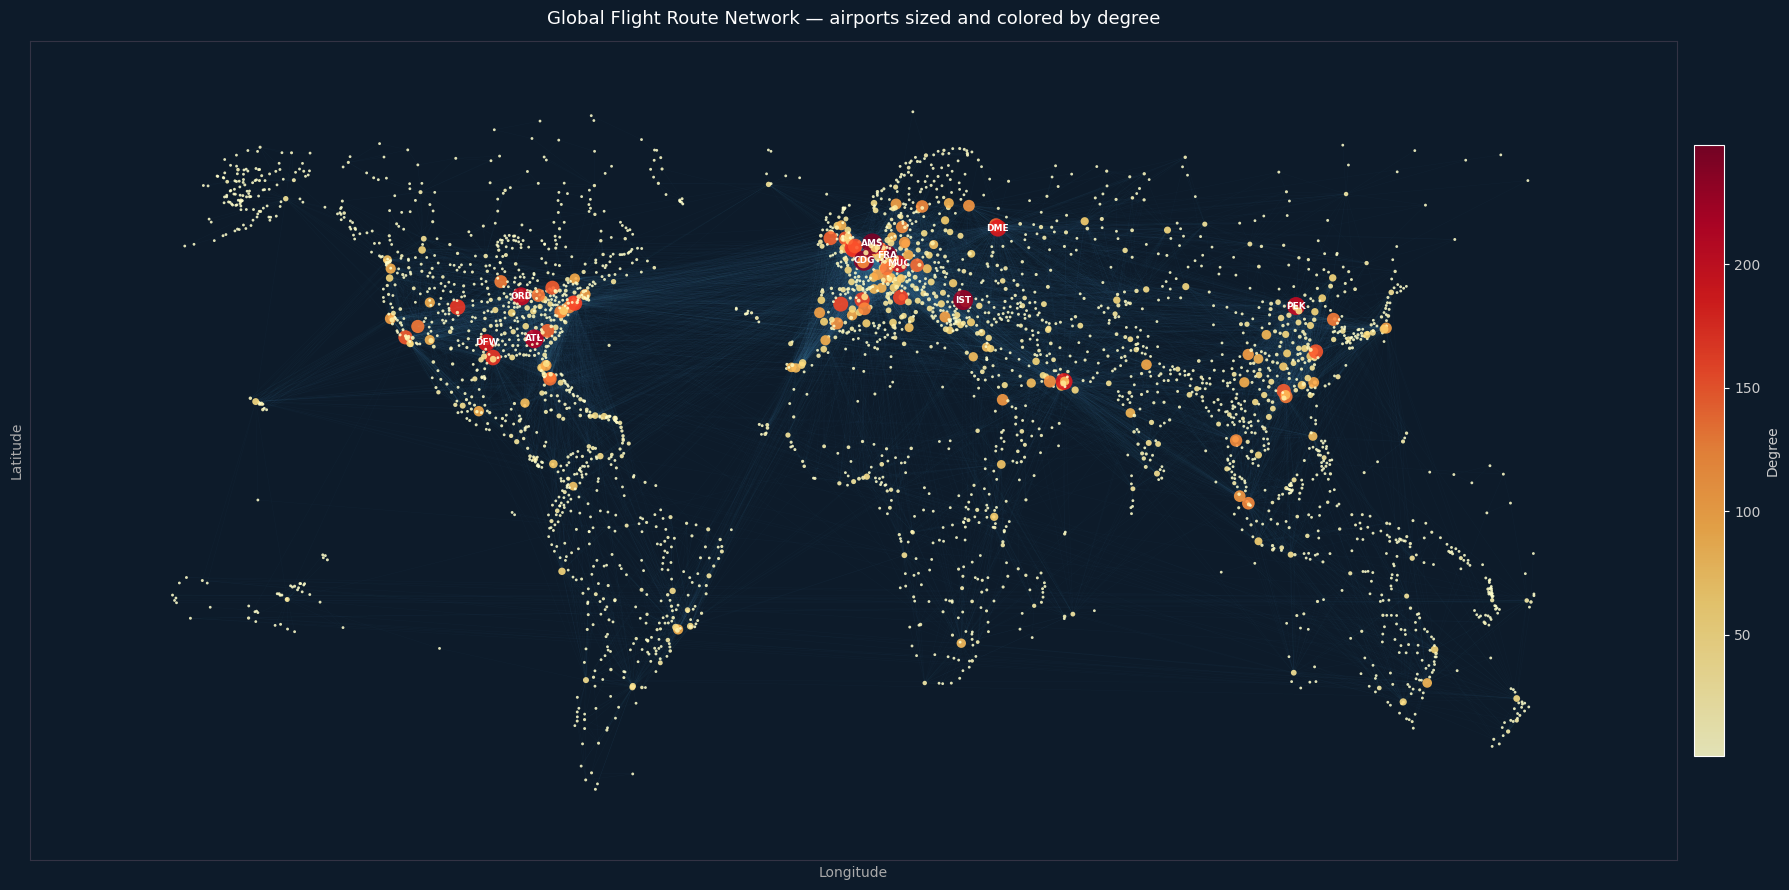

Saved: flight_network_geographic.png


In [13]:
# Build position dict from geographic coordinates
pos = {
    node: (data['lon'], data['lat'])
    for node, data in G.nodes(data=True)
    if data.get('lon') is not None and data.get('lat') is not None
}

G_vis = G.subgraph(pos.keys())
vis_nodes = list(G_vis.nodes())
vis_deg = dict(G_vis.degree())
max_deg = max(vis_deg.values())

node_sizes = [4 + 220 * (vis_deg[n] / max_deg) ** 1.5 for n in vis_nodes]
node_colors = [vis_deg[n] for n in vis_nodes]

fig, ax = plt.subplots(figsize=(18, 9))
ax.set_facecolor('#0d1b2a')
fig.patch.set_facecolor('#0d1b2a')

nx.draw_networkx_edges(
    G_vis, pos, ax=ax,
    alpha=0.04, edge_color='#5ba3d0', width=0.35,
)
sc = nx.draw_networkx_nodes(
    G_vis, pos, nodelist=vis_nodes, ax=ax,
    node_size=node_sizes, node_color=node_colors,
    cmap=plt.cm.YlOrRd, alpha=0.88, linewidths=0,
)
hub_labels = {iata: iata for iata, _ in top10[:12] if iata in pos}
nx.draw_networkx_labels(
    G_vis, pos, labels=hub_labels, ax=ax,
    font_size=6.5, font_color='white', font_weight='bold',
)

cbar = plt.colorbar(sc, ax=ax, fraction=0.018, pad=0.01)
cbar.set_label('Degree', color='#cccccc', fontsize=10)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#cccccc')

ax.set_title(
    'Global Flight Route Network — airports sized and colored by degree',
    fontsize=13, color='white', pad=12,
)
ax.set_xlabel('Longitude', color='#aaaaaa', fontsize=10)
ax.set_ylabel('Latitude', color='#aaaaaa', fontsize=10)
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#333344')

plt.tight_layout()
plt.savefig('flight_network_geographic.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1b2a')
plt.show()
print('Saved: flight_network_geographic.png')


### 5.2 Degree distribution


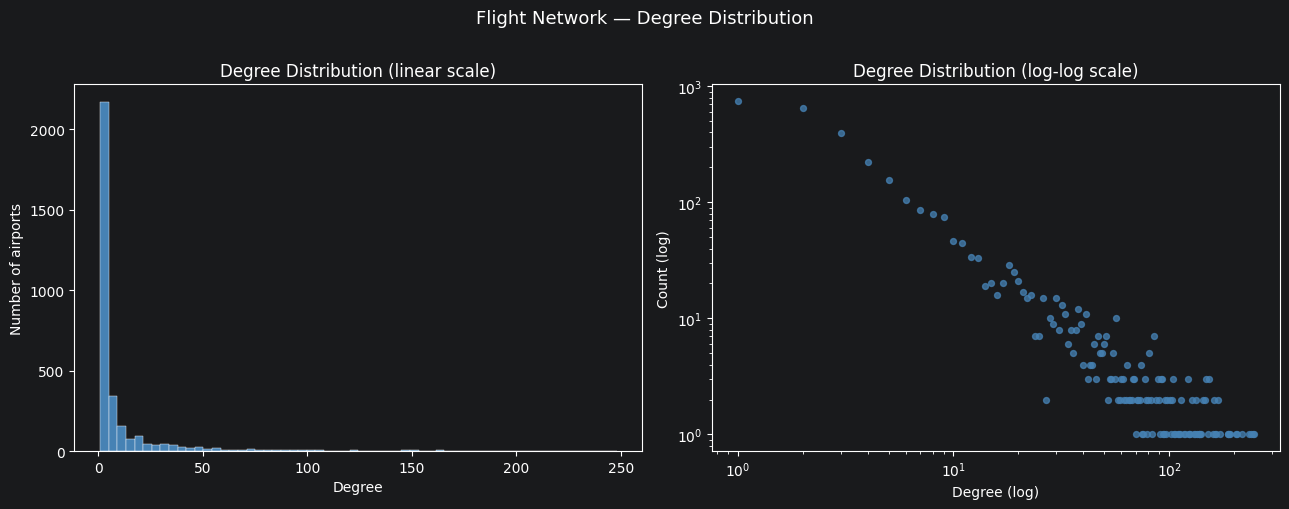

Saved: flight_network_degree_dist.png


In [14]:
deg_cnt = Counter(deg_arr.tolist())
x_vals = sorted(deg_cnt.keys())
y_vals = [deg_cnt[d] for d in x_vals]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Linear histogram
axes[0].hist(deg_arr, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Number of airports')
axes[0].set_title('Degree Distribution (linear scale)')

# Log-log scatter
axes[1].scatter(x_vals, y_vals, s=18, color='steelblue', alpha=0.75)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Degree (log)')
axes[1].set_ylabel('Count (log)')
axes[1].set_title('Degree Distribution (log-log scale)')

plt.suptitle('Flight Network — Degree Distribution', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('flight_network_degree_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: flight_network_degree_dist.png')


## 6. Reflection

**Answering the four Exercise 02 questions:**

1. **Node/edge counts, density, and degree pattern.**
   The network has roughly 3,000 airports and 17,000 edges, giving a density well below 0.01
   — each airport connects directly to only a small fraction of all others.
   Yet the degree distribution is strongly right-skewed: a handful of mega-hubs (Frankfurt,
   Istanbul, London Heathrow, Charles de Gaulle, …) connect to hundreds of airports,
   while the majority serve only a few regional or domestic routes.
   This heavy-tailed pattern is a hallmark of hub-and-spoke infrastructure.

2. **One meaningful shortest path.**
   Despite low density, any two airports in the giant component are reachable in 2–3 hops.
   The top-degree hub (see path above) acts as a relay that shortens almost every journey:
   fly to the hub, then fly out. This is the small-world property in action.

3. **What the visualization tells us about structure.**
   The geographic layout immediately reveals real-world clustering: dense airport clouds
   over Europe, the US East Coast, East Asia, and the Middle East;
   sparse coverage over the Pacific, sub-Saharan Africa, and the Arctic.
   Hub airports stand out as large bright nodes at continental crossroads.
   The faint edge network traces recognisable intercontinental corridors.

4. **How Lecture 02 concepts helped.**
   Representing airports as nodes and routes as edges turned a timetable into a mathematical
   object we can query. Degree told us which airports are most connected without any prior
   knowledge of airline strategy. Connected-component analysis confirmed that the global
   network is almost entirely one giant component — a structural fact with real resilience
   implications. Shortest paths operationalised the intuition that "you can always get
   there in a connection or two." These are the primitives; later lectures will layer
   centrality, communities, and dynamics on top of the same graph.
